In [1]:
using Distributed
addprocs(10)
@everywhere include("1_timed_old_proc.jl")

In [3]:
A, tim = @timed pmap(rangeexp, 1:10)
tim

9.0322092

In [4]:
A[25]

(Float32[1.0 0.99959093 … 0.9732729 0.9668654; 1.0 0.99947923 … 0.9586244 0.9613587; … ; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0], Int32[109 102 … 105 96; 96 99 … 104 91; … ; 0 0 … 0 0; 0 0 … 0 0])

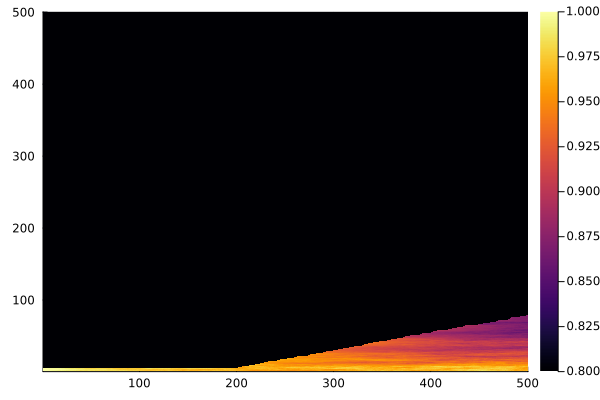

In [4]:
using Plots
heatmap(A[4],clim=(0.8,1.0))

In [5]:
@show A[5][:,end]

(A[5])[:, end] = Float32[0.9923758, 0.9955822, 0.97939193, 0.9848368, 0.97996944, 0.9692928, 0.95303434, 0.95499045, 0.94988346, 0.95303875, 0.9497659, 0.9386581, 0.94253165, 0.9313697, 0.91866803, 0.94011235, 0.9423296, 0.9392738, 0.93975794, 0.95390177, 0.94111377, 0.93474597, 0.92686254, 0.9278746, 0.93455625, 0.92555964, 0.924376, 0.92501515, 0.92748773, 0.9240711, 0.9143871, 0.92784053, 0.933393, 0.92462194, 0.9314973, 0.92581123, 0.9107446, 0.9112698, 0.9205391, 0.9202714, 0.9151519, 0.9177977, 0.92188954, 0.9236457, 0.9255439, 0.9301327, 0.9240105, 0.9283871, 0.9310182, 0.93133533, 0.9368258, 0.94016343, 0.9308599, 0.9282687, 0.9288903, 0.931786, 0.933434, 0.93034136, 0.93536264, 0.9314921, 0.93017447, 0.9316044, 0.930088, 0.9272173, 0.92403454, 0.9140828, 0.93283767, 0.9346588, 0.94100344, 0.9362693, 0.9356935, 0.93078196, 0.93320346, 0.9317401, 0.9347731, 0.93459153, 0.93059707, 0.93764454, 0.93779755, 0.93987316, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.

500-element Vector{Float32}:
  0.9923758
  0.9955822
  0.97939193
  0.9848368
  0.97996944
  0.9692928
  0.95303434
  0.95499045
  0.94988346
  0.95303875
  ⋮
 -1.0
 -1.0
 -1.0
 -1.0
 -1.0
 -1.0
 -1.0
 -1.0
 -1.0

In [14]:
indicess = [findlast(x -> x >= 0, A[j]) for j in 1:25]
last_valid_index = mean(ci.I[1] for ci in indicess)

81.36

In [15]:
using Statistics

stacked = cat(A...; dims=3)
avg = mapslices(x -> mean(filter(!=(-1.0), x)), stacked; dims=3)[:, :, 1]


500×500 Matrix{Float32}:
   1.0    0.999631    0.999184  …    0.977164    0.977443    0.977848
   1.0    0.999596    0.999237       0.977002    0.976605    0.977401
   1.0    0.99961     0.999213       0.976263    0.976575    0.977424
   1.0    0.999618    0.99922        0.976573    0.976877    0.97718
   1.0    0.999655    0.999206       0.978221    0.978201    0.97807
 NaN    NaN         NaN         …    0.971488    0.97157     0.971656
 NaN    NaN         NaN              0.965829    0.965819    0.965365
 NaN    NaN         NaN              0.959336    0.960414    0.960341
 NaN    NaN         NaN              0.951788    0.952716    0.953334
 NaN    NaN         NaN              0.947937    0.948698    0.948448
   ⋮                            ⋱                          
 NaN    NaN         NaN            NaN         NaN         NaN
 NaN    NaN         NaN            NaN         NaN         NaN
 NaN    NaN         NaN            NaN         NaN         NaN
 NaN    NaN         NaN     

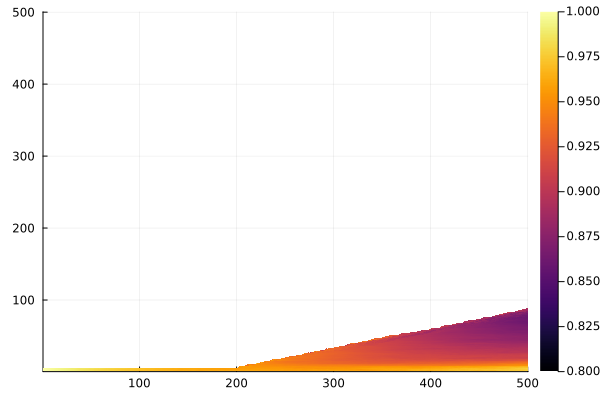

In [17]:
using Plots
heatmap(avg,clim=(0.8,1.0))

In [16]:
avg[findlast(x -> !isnan(x), avg)]

0.8910243f0

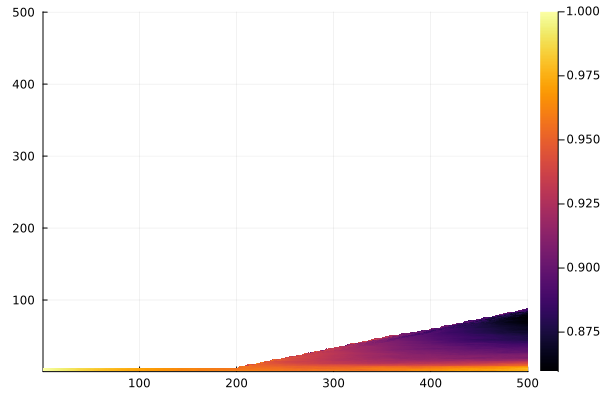

In [18]:
heatmap(avg)

---

In [1]:
using Distributed
addprocs(10)
@everywhere include("1_timed_old_proc.jl")
# Turn on pops_out for this

In [4]:
A, tim = @timed pmap(rangeexp, 1:10)
tim

32.2542736

In [7]:
fits = getfield.(A, 1)

10-element Vector{Matrix{Float32}}:
 [1.0 0.99954545 … 1.4294161 1.4334314; 1.0 0.99938154 … 1.4184922 1.4167868; … ; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0]
 [1.0 0.9996068 … 1.3084599 1.3056777; 1.0 0.99939835 … 1.3138245 1.3155833; … ; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0]
 [1.0 0.99936175 … 1.4836667 1.4815297; 1.0 0.99960023 … 1.5056499 1.5057181; … ; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0]
 [1.0 0.9992251 … 1.3895992 1.387293; 1.0 0.99924994 … 1.4153013 1.4146482; … ; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0]
 [1.0 0.9996847 … 1.382413 1.3826466; 1.0 0.99966 … 1.3657799 1.3636909; … ; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0]
 [1.0 0.99994284 … 1.3268248 1.326713; 1.0 0.9997 … 1.3159902 1.3193523; … ; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0]
 [1.0 0.99954545 … 1.4815459 1.4848256; 1.0 0.9999999 … 1.4948453 1.4936359; … ; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0]
 [1.0 0.99960786 … 1.4664321 1.4711621; 1.0 0.9994218 … 1.4707001 1.4690677; … ; -

In [10]:
stacked = replace!(cat(fits...; dims=ndims(fits[1]) + 1),-1=>0)

500×2000×10 Array{Float32, 3}:
[:, :, 1] =
 1.0  0.999545  0.998764  0.998968  …  1.42675  1.42698  1.42942  1.43343
 1.0  0.999382  0.998836  0.998227     1.42197  1.4202   1.41849  1.41679
 1.0  0.999468  0.999118  0.998799     1.44588  1.44246  1.43877  1.43986
 1.0  0.999657  0.999316  0.999187     1.43962  1.43878  1.43315  1.42977
 1.0  0.99972   0.999386  0.998955     1.42629  1.4353   1.44121  1.43773
 0.0  0.0       0.0       0.0       …  1.44072  1.4427   1.44148  1.445
 0.0  0.0       0.0       0.0          1.42658  1.43073  1.4362   1.42998
 0.0  0.0       0.0       0.0          1.41298  1.41282  1.40938  1.40938
 0.0  0.0       0.0       0.0          1.40796  1.40629  1.40816  1.40878
 0.0  0.0       0.0       0.0          1.3816   1.38016  1.37963  1.39341
 ⋮                                  ⋱                             
 0.0  0.0       0.0       0.0          0.0      0.0      0.0      0.0
 0.0  0.0       0.0       0.0          0.0      0.0      0.0      0.0
 0.0  0.0   

In [11]:
avg_fitness = mean(stacked; dims=ndims(stacked))[:,:,end]

500×2000 Matrix{Float32}:
 1.0  0.999582  0.999058  0.998712  …  1.4226   1.42361  1.4244   1.42468
 1.0  0.999574  0.999214  0.998884     1.43107  1.43124  1.43099  1.42991
 1.0  0.999531  0.999257  0.998678     1.44231  1.44312  1.44258  1.44333
 1.0  0.999637  0.999275  0.998867     1.44172  1.44287  1.44239  1.44473
 1.0  0.999622  0.999228  0.99879      1.44989  1.45322  1.45346  1.45352
 0.0  0.0       0.0       0.0       …  1.44448  1.44681  1.44823  1.44889
 0.0  0.0       0.0       0.0          1.44081  1.44108  1.44315  1.44402
 0.0  0.0       0.0       0.0          1.43739  1.43572  1.43512  1.43643
 0.0  0.0       0.0       0.0          1.43511  1.4371   1.4371   1.4374
 0.0  0.0       0.0       0.0          1.44232  1.44168  1.44184  1.44409
 ⋮                                  ⋱                             
 0.0  0.0       0.0       0.0          0.0      0.0      0.0      0.0
 0.0  0.0       0.0       0.0          0.0      0.0      0.0      0.0
 0.0  0.0       0.0       0.

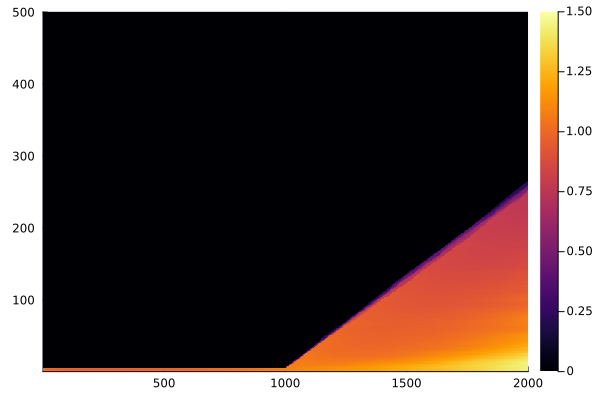

In [12]:
using Plots
heatmap(avg_fitness,clim=(0,1.5))

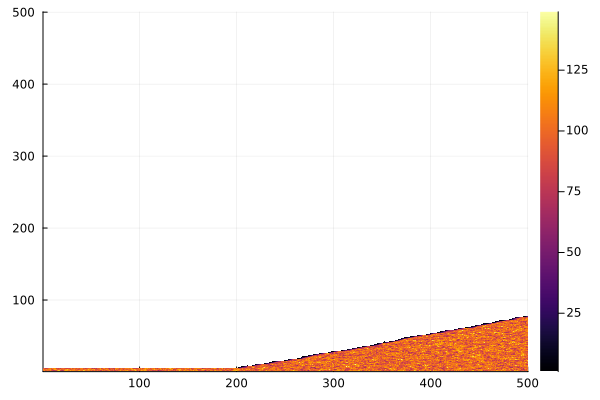

In [3]:
using Plots
heatmap(replace(A[1][2], 0.0 => NaN))

---

In [1]:
include("1_timed_old_proc.jl")

rangeexp (generic function with 4 methods)

In [2]:
A1 = rangeexp(-1,10,10;pops_out=true,verbose=true)

Int16[93, 103, 96, 91, 100, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, 

(Float32[1.0 0.99942714 … 0.99753135 0.99736786; 1.0 0.999703 … 0.9977105 0.99758166; … ; -1.0 -1.0 … -1.0 -1.0; -1.0 -1.0 … -1.0 -1.0], Int32[93 118 … 94 85; 103 108 … 90 91; … ; 0 0 … 0 0; 0 0 … 0 0])

In [3]:
A1[2]

500×10 Matrix{Int32}:
  93  118  111  111   99   86   92   86   94   85
 103  108   96   94  109  104   97  100   90   91
  96  110  110   95  108   92   90   94  103  104
  91   83   83   93  102  113  124  105   99  104
 100  106  106  116  106   91   86   89  106   99
   0    0    0    0    0    0    0    0    0    0
   0    0    0    0    0    0    0    0    0    0
   0    0    0    0    0    0    0    0    0    0
   0    0    0    0    0    0    0    0    0    0
   0    0    0    0    0    0    0    0    0    0
   ⋮                        ⋮                 
   0    0    0    0    0    0    0    0    0    0
   0    0    0    0    0    0    0    0    0    0
   0    0    0    0    0    0    0    0    0    0
   0    0    0    0    0    0    0    0    0    0
   0    0    0    0    0    0    0    0    0    0
   0    0    0    0    0    0    0    0    0    0
   0    0    0    0    0    0    0    0    0    0
   0    0    0    0    0    0    0    0    0    0
   0    0    0    0    0    0  

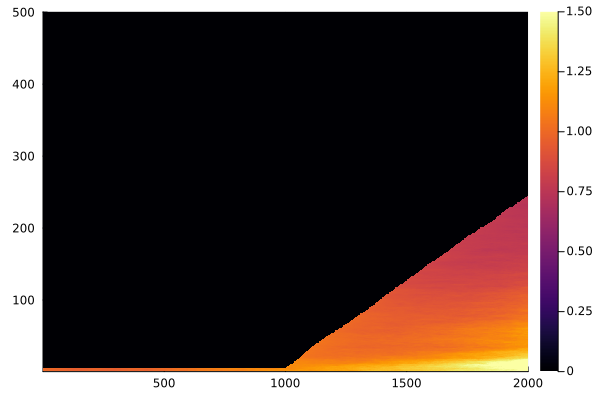

In [12]:
using Plots
heatmap(A1[1],clim=(0,1.5))

---

In [1]:
using Distributed
addprocs(30)
@everywhere include("1_timed_old_proc.jl")
# Turn on pops_out for this

In [4]:
A, tim = @timed pmap(rangeexp, 1:30)
tim

7.4245785

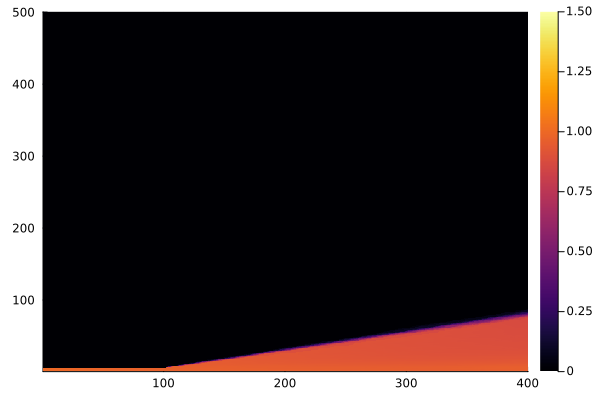

In [5]:
fits = getfield.(A, 1)
stacked = replace!(cat(fits...; dims=ndims(fits[1]) + 1),-1=>0)
avg_fitness = mean(stacked; dims=ndims(stacked))[:,:,end]
using Plots
heatmap(avg_fitness,clim=(0,1.5))